In [14]:
from pathlib import Path
from random import choice
from random import seed
from PIL import Image
from arrow import now
from cv2 import imread
from cv2 import resize
from numpy import array
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import Sequential
from tensorflow.keras.regularizers import l2
import numpy as np
from tensorflow import keras
from time import time as now
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
seed(2023)

data = Path('/kaggle/input/dog-and-cat-classification-dataset/PetImages')
files = list(data.glob('**/*.jpg'))
cat_files = list(data.glob('Cat/*.jpg'))
dog_files = list(data.glob('Dog/*.jpg'))
for _ in range(5):
    print(choice(files))

/kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat/1075.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat/63.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat/4252.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat/7440.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/8963.jpg


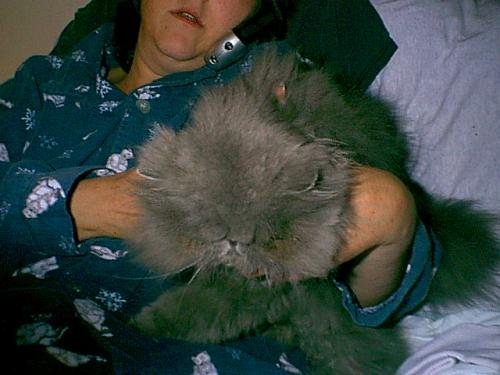

In [3]:
Image.open(mode='r', fp=str(choice(cat_files)))

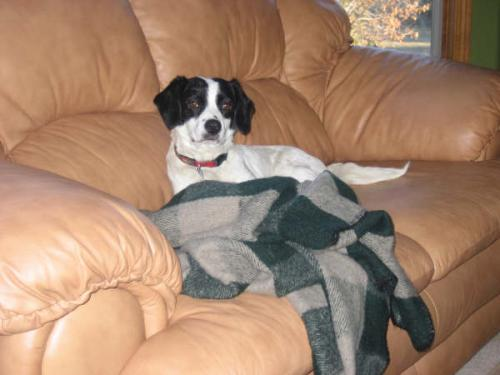

In [4]:
Image.open(mode='r', fp=str(choice(dog_files)))

In [5]:
load_start = now()
animals = {'cat': list(data.glob('Cat/*.*'))[:1000], 'dog': list(data.glob('Dog/*.*'))[:1000],}
labels = {'cat': 0, 'dog': 1}
# todo is there any way to build these using list comprehensions?
X = []
Y = []
missing_image_count = 0
success_files = []

for name, file_list in animals.items():
    label = labels[name]
    for filename in tqdm(file_list):
        try:
            image = imread(str(filename).strip())
            if image is not None:
                image_resized = resize(image, (200, 200))  # Resize to (200, 200, 3)
                X.append(image_resized.flatten())  # Flatten to 1D
                Y.append(label)
                success_files.append(filename)
            else:
                missing_image_count += 1
        except Exception:
            pass  # Handle exceptions silently

100%|██████████| 1000/1000 [00:08<00:00, 112.44it/s]


In [6]:
# Convert lists to NumPy arrays
X = np.array(X, dtype=np.float32) / 255.0  # Normalize pixel values
Y = np.array(Y, dtype=np.int32)

# Print summary
print(f'Array lengths: X: {len(X)} Y: {len(Y)}')
print(f'X shape: {X.shape}')  # Should be (num_samples, 120000)
print(f'Missing {missing_image_count} images')

Array lengths: X: 1996 Y: 1996
X shape: (1996, 120000)
Missing 4 images


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, shuffle=True, test_size=0.2, random_state=2023, stratify=Y
)

In [8]:
EPOCHS = 12

model_start = now()
model = keras.Sequential([
    keras.layers.Input(shape=(120000,)),  # Correct input shape for 200x200x3 images
    keras.layers.Dense(128, activation='relu'),  # Hidden Layer 1
    keras.layers.Dense(64, activation='relu'),  # Hidden Layer 2
    keras.layers.Dense(32, activation='relu'),  # Hidden Layer 3
    keras.layers.Dense(1, activation='sigmoid')  # Binary classification (0=Cat, 1=Dog)
])

model.compile(
    loss='binary_crossentropy',
    metrics=['accuracy'],  # No need for 'binary_accuracy'
    optimizer='adam',
)

# Train the model
fit_history = model.fit(x=X_train, y=y_train, epochs=EPOCHS, batch_size=32, validation_split=0.2)

# Evaluate on test set
evaluate_result = model.evaluate(x=X_test, y=y_test, batch_size=32, verbose=1)
print(evaluate_result)
print('Model training time: {:.2f} seconds'.format(now() - model_start))


Epoch 1/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.5099 - loss: 4.8734 - val_accuracy: 0.5094 - val_loss: 2.0057
Epoch 2/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5196 - loss: 1.7925 - val_accuracy: 0.5094 - val_loss: 2.1647
Epoch 3/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4985 - loss: 1.3868 - val_accuracy: 0.5188 - val_loss: 1.6143
Epoch 4/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5538 - loss: 1.2187 - val_accuracy: 0.5531 - val_loss: 0.8461
Epoch 5/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6373 - loss: 0.7784 - val_accuracy: 0.5844 - val_loss: 0.6906
Epoch 6/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6360 - loss: 0.7064 - val_accuracy: 0.5625 - val_loss: 0.8886
Epoch 7/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5768 - loss: 0.8821 - val_accuracy: 0.6031 - val_loss: 0.7165
Epoch 8/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6666 - loss: 0.6393 - val_accuracy: 0.5281 - v

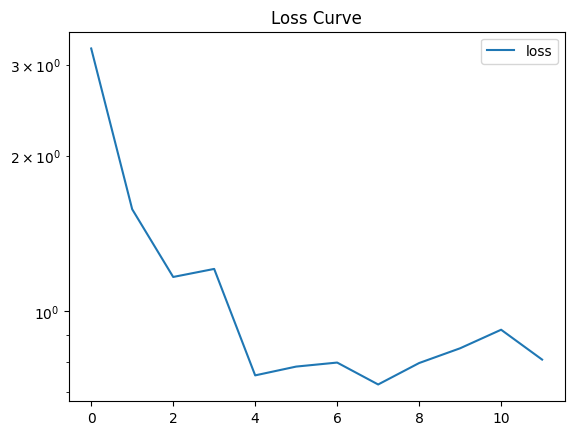

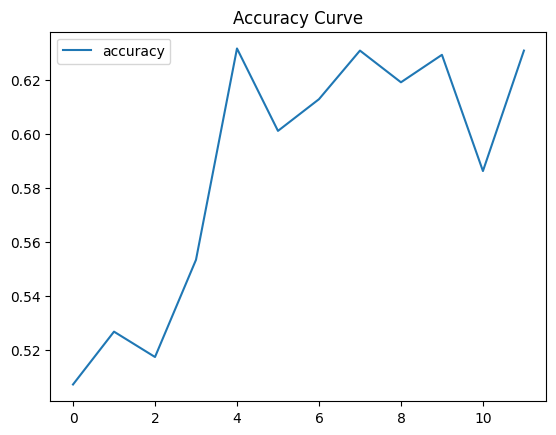

In [15]:
# Convert training history to DataFrame
history_df = pd.DataFrame(fit_history.history)

# Plot loss (log scale for better visualization)
history_df[['loss']].plot(logy=True, title="Loss Curve")
plt.show()

# Plot accuracy
history_df[['accuracy']].plot(title="Accuracy Curve")
plt.show()

In [17]:
from random import randint
from random import seed
seed(2023)

total = 0
correct = 0
checks = []
for _ in range(100):
    index = randint(0, len(X))
    checks.append(index)
    model_result = model(X[index].reshape(1, -1), training=False)
    value = model_result.numpy()[0][0]
    binary_value = 0 if value < 0.5 else 1
    correct += 1 if  binary_value == Y[index] else 0
    print(index, value, binary_value, Y[index], binary_value == Y[index])
    total += 1
print(round(correct / total, 2))

784 0.8127967 1 0 False
1436 0.91208637 1 1 True
1990 0.9081796 1 1 True
914 0.6723437 1 0 False
1728 0.9582391 1 1 True
797 0.6704728 1 0 False
655 0.7319025 1 0 False
1251 0.9559138 1 1 True
1169 0.6323753 1 1 True
1911 0.84619987 1 1 True
690 0.6182325 1 0 False
1297 0.8758999 1 1 True
204 0.4866024 0 0 True
1606 0.8258106 1 1 True
253 0.879728 1 0 False
1333 0.84437853 1 1 True
621 0.489519 0 0 True
1717 0.9890161 1 1 True
1427 0.76428896 1 1 True
1089 0.88835204 1 1 True
1471 0.8323789 1 1 True
1080 0.9313321 1 1 True
616 0.65023935 1 0 False
364 0.7272415 1 0 False
476 0.7339864 1 0 False
1876 0.92121077 1 1 True
1899 0.7828501 1 1 True
361 0.2516364 0 0 True
1305 0.54572386 1 1 True
34 0.48307326 0 0 True
431 0.7822152 1 0 False
743 0.5622284 1 0 False
143 0.38070074 0 0 True
1276 0.8196601 1 1 True
258 0.8656192 1 0 False
1443 0.9857554 1 1 True
1739 0.62529266 1 1 True
1602 0.67405486 1 1 True
79 0.7851511 1 0 False
409 0.7086745 1 0 False
316 0.90336853 1 0 False
1989 0.77159

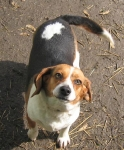

In [21]:
Image.open(mode='r', fp=success_files[checks[1]])